In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# for matrix creation and solving
import scipy.sparse
from scipy.sparse import diags_array
from scipy.sparse.linalg import spsolve

# stolen from workshops, six items in each
markers = ['x', 's', 'd', '+', 'o', '.']
colours = ['xkcd:salmon', 'xkcd:golden rod', 'xkcd:teal', 'xkcd:purple', 'xkcd:slate',' xkcd:silver']    

## Problem Introduction
The one-dimensional diffusion equation is 
$$
    \partial_t C(x,t) = D\partial_{xx}C(x, t)
$$
for some diffusion coefficient $D$. Consider this equation over some interval $[-L, L]$ with non-negative time $t \geq 0$. We can nondimensionalise this system by writing
$$
    \xi = \frac{x}{L}, \quad \tau = \frac{Dt}{L^2}, \quad u(\xi, \tau) = LC(x,t)\tag{1}
$$
where the subsequent system becomes
$$
\partial_\tau u(\xi, \tau) = \partial_{\xi\xi}(\xi, \tau)\tag{2}
$$
over $\xi \in [-1, 1]$ and again $\tau \geq 0$. This can be verified with the chain rule, i.e.
$$
\frac{\partial}{\partial t}C = \frac{\partial}{\partial \tau}\frac{\partial \tau}{\partial t}C, \qquad \frac{\partial^2}{\partial x^2}C = \frac{\partial}{\partial \xi}\frac{\partial \xi}{\partial x}\frac{\partial}{\partial \xi}\frac{\partial \xi}{\partial x}.
$$

Neumann boundary conditions are imposed by setting $\partial_\xi u(-1, \tau) = \partial_\xi u(1, \tau) = 0$. We want all of our concentration at the origin at $t=0$, i.e. $u(\xi, 0) = 1$ if $\xi = 0$ and $u(\xi, 0) = 0$ if $\xi \neq 0$.


## Numerical Implementation
Let $U$ be the matrix representation the numerical solution of this (nondimensional) system such that $U_m^n = U(x_m, t_n)$. The backwards Euler method updates $U$ with
$$  
    U_m^n = -CU_{m+1}^{n+1} + (1+2C)U_m^{n+1} - CU_{m-1}^{n+1},\qquad C = \frac{D\Delta t}{(\Delta x)^2}
$$
where $\Delta t$ and $\Delta x$ are the time/space step sizes respectively. Backwards Euler has been chosen because it is stable for any $C>0$, so we can have 'decoupled' steps. This can be written in the form $AU^{n+1} = U^n$, where $A$ is a square matrix completely independent of space or time
$$
\begin{bmatrix}
1 & 0 & 0 & 0 & \cdots & 0 & 0 \\
-C & 1 + 2C & -C & 0 & \cdots & 0 & 0 \\
0 & -C & 1 + 2C & -C & \cdots & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \ddots & 0 & 0 \\
0 & 0 & 0 & 0 & -C & 1 + 2C & -C \\
0 & 0 & 0 & 0 & \cdots & 0 & 1
\end{bmatrix}
\begin{bmatrix}
U_0^{n+1} \\[4pt]
U_1^{n+1} \\[4pt]
U_2^{n+1} \\[4pt]
\vdots \\[4pt]
U_{M-1}^{n+1} \\[4pt]
U_M^{n+1}
\end{bmatrix}
=
\begin{bmatrix}
U_0^{n} \\[4pt]
U_1^{n} \\[4pt]
U_2^{n} \\[4pt]
\vdots \\[4pt]
U_{M-1}^{n} \\[4pt]
U_M^{n}
\end{bmatrix}
.
$$

To impose the Neumann boundary conditions, we use the centred difference approximation
$$
\begin{align*}
    U_0^n &= (1+2C)U_0^{n+1} -2CU_1^{n+1}\\
    U_M^n &= -2CU_{M-1}^{n+1} + (1+2C)U_M^{n+1}.
\end{align*}
$$
outlined in the week two workshop. Thus we need to modify the first and final row in our matrix $A$ such that

$$
\begin{bmatrix}
1+2C & -2C & 0 & 0 & \cdots & 0 & 0 \\
-C & 1 + 2C & -C & 0 & \cdots & 0 & 0 \\
0 & -C & 1 + 2C & -C & \cdots & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \ddots & 0 & 0 \\
0 & 0 & 0 & 0 & -C & 1 + 2C & -C \\
0 & 0 & 0 & 0 & \cdots & -2C & 1+2C
\end{bmatrix}
\begin{bmatrix}
U_0^{n+1} \\[4pt]
U_1^{n+1} \\[4pt]
U_2^{n+1} \\[4pt]
\vdots \\[4pt]
U_{M-1}^{n+1} \\[4pt]
U_M^{n+1}
\end{bmatrix}
=
\begin{bmatrix}
U_0^{n} \\[4pt]
U_1^{n} \\[4pt]
U_2^{n} \\[4pt]
\vdots \\[4pt]
U_{M-1}^{n} \\[4pt]
U_M^{n}
\end{bmatrix}
.
$$
Only the first and last row have been altered. Notice that $A$ is necessarily a square matrix of dimenison $M + 1$ since it acts on $[U_0^{n+1}, \dots, U_M^{n+1}]$ and is invertible. 

The `diags_array` method from SciPy generates a *sparse* array type. This reduces the amount of memory needed to store the array, and lets us easily use computationally efficient methods to find its inverse later. [See the docs here.](https://docs.scipy.org/doc/scipy-1.12.0/reference/generated/scipy.sparse.diags_array.html)

In [2]:
# n is time, m is space
# number of time/space steps, and the final time
N, M, T = 2000, 250, 10
start_time = 0.01
t = np.linspace(0 + start_time, T, N + 1)
x = np.linspace(-1, 1, M + 1)

# step sizes and constant term C
dx = x[1] - x[0]
dt = t[1] - t[0]
C = dt / (dx**2)

# A is square, dimension M+1
main_diag = np.array(([1+2*C] * (M+1)))
super_diag = np.array([-2*C] + ([-C] * (M-1)))
sub_diag = np.array(([-C]*(M-1)) + [-2*C])

# storing as csr matrix lets use us spsolve
A = diags_array([main_diag, super_diag, sub_diag], offsets = [0, 1, -1], format = 'csr')
print(A.toarray())

[[ 157.09375  -156.09375     0.       ...    0.          0.
     0.      ]
 [ -78.046875  157.09375   -78.046875 ...    0.          0.
     0.      ]
 [   0.        -78.046875  157.09375  ...    0.          0.
     0.      ]
 ...
 [   0.          0.          0.       ...  157.09375   -78.046875
     0.      ]
 [   0.          0.          0.       ...  -78.046875  157.09375
   -78.046875]
 [   0.          0.          0.       ...    0.       -156.09375
   157.09375 ]]


Now we need to implement our initial conditions. In one of the workshops Ben suggested that we should try to implement a smooth function for our numerics, instead of the sharp spike at zero.

I've chosen to use 
    $$
    I(x) = \begin{cases}
            \cos\big(\tfrac{\pi x}{2r}\big), \quad &|x| \leq r,\\
            0, &\text{otherwise}
        \end{cases}
    $$
because it's (piecewise) smooth and easy to implement. The parameter $r$ determines how narrow the curve is, [graphed it on Desmos if you like.](https://www.desmos.com/calculator/5f8fjhobov) Using $r = 3\Delta x$ seems reasonable at first.

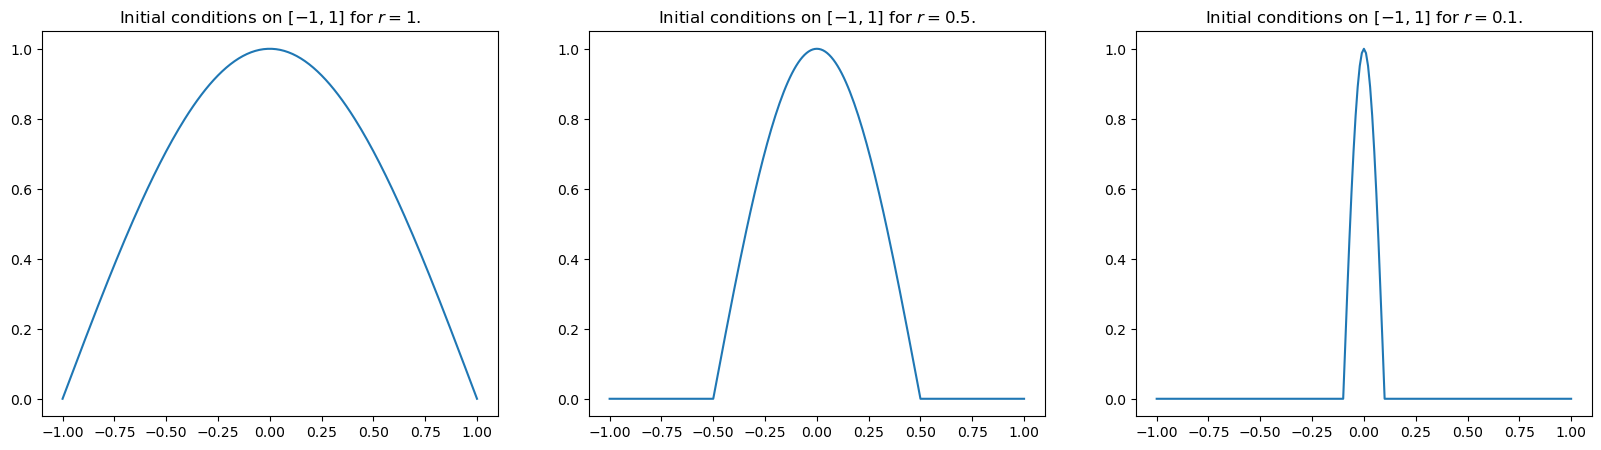

In [3]:
def I(x, r):
    '''
    Evaluates the initial condition I(x) for x and a user-supplied
    range r. 

    Output:
        initial_x (float) : the initial value of x
    '''

    initial_x = np.zeros_like(x, dtype = float)

    # masking creates a boolean array
    mask = np.abs(x) <= r
    initial_x[mask] = np.cos((np.pi * x[mask]) / (2*r))
    
    return initial_x

# Testing
x_test = np.arange(-1, 1 + 0.01, 0.01)
fig, axes = plt.subplots(1, 3, figsize = (20, 5))
for ax, r in zip(axes, [1, 0.5, 0.1]):
    ax.plot(x_test, I(x_test, r))
    ax.set_title(f'Initial conditions on $[-1, 1]$ for $r = {round(r, 2)}$.')

plt.show()

All that's left is to iterate through each one-step update. Because $A$ is sparse, we can use SciPy's `spsolve` to compute the inverse $A^{-1}$. The numerical solution can be compared to the analytical solution that was found to be
$$
u(\xi, \tau) = \frac{1}{2} + \lim_{N \rightarrow \infty} \sum_{n=1}^N \cos(n\pi\xi)\exp(-(n\pi)^2\tau).
$$
When doing this comparison we can truncate for an appropriately large $N$.

In [4]:
def analytical_sol(x, t, N):   
    '''
    Gives the exact solution as outlined above.
    Input:
        x (list): the entire space of the system
        t (float): the *particular* time to evaluate the solution at
        N (int): number of terms to approximate the infinite series by
        
    '''
    
    exact_sol = np.zeros_like(x, dtype = float)
    exact_sol += 1/2

    for n in range(1, N):
        exact_sol += np.cos(n*np.pi*x) * np.exp(-1*((n*np.pi)**2)*t)
    
    return exact_sol

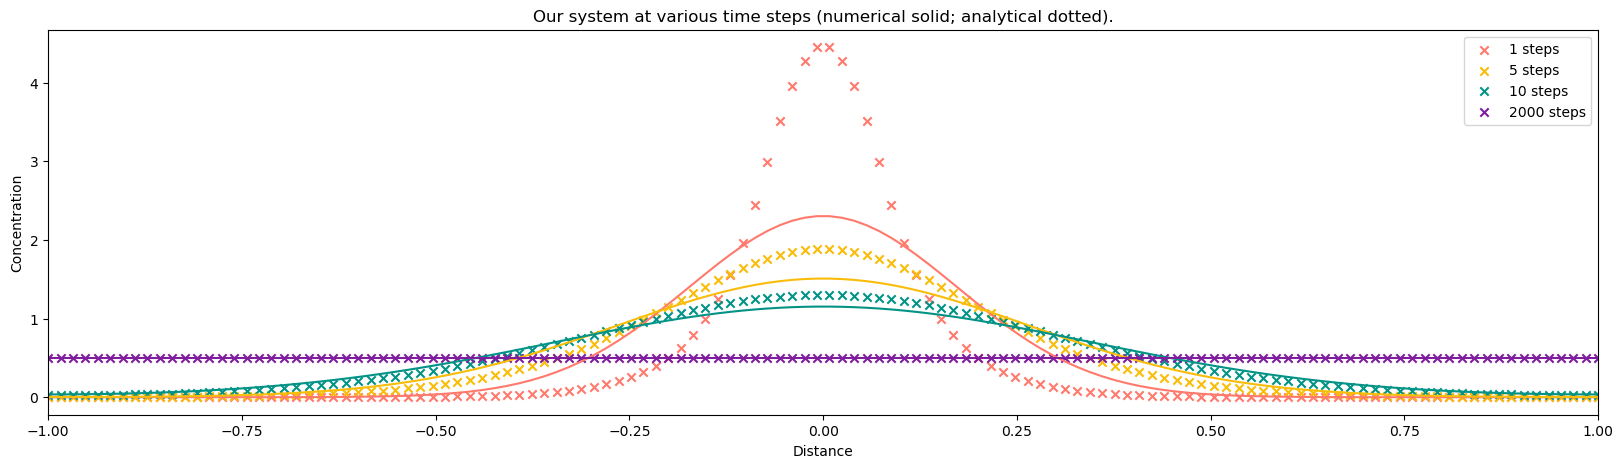

System uses N = 2000 time points, M = 250 space points, a total time of T = 10, with dt, dx = 0.004995000000000001, 0.008000000000000007.


In [5]:
# recall again: n is time, m is space
r = 0.1
U = np.zeros((N+1, M+1))

# see below discussion
U[0] = I(x, r)
U[0] = (np.pi / (4*r)) * U[0]

# Also store exact solution
U_ex = np.zeros((N+1, M+1))

for n in range(0, N):
    pseudo_inv = spsolve(A, U[n])
    U[n + 1] = pseudo_inv

times = [1, 5, 10, N]
fig, ax = plt.subplots(1, 1, figsize = (20, 5))

# for ax, time in zip(axes, times):
for i, time in enumerate(times):
    ax.scatter(x[::2], U[time][::2], label = f'{time} steps', color = colours[i], marker = 'x')

    # exact ics might preserve mass but they're awful
    if (time > 0):
        ax.plot(x[::2], analytical_sol(x[::2], t[time], int(1e5)), color = colours[i])
    
    ax.set_title(f'Our system at various time steps (numerical solid; analytical dotted).')
    ax.set_xlabel("Distance")
    ax.set_ylabel("Concentration")
    ax.set_xlim(-1, 1)

# ax.plot(x[::2], [0.01] * len(x[::2]), color = "black", linestyle = 'dashed')

plt.legend(loc = 'best')
plt.show()

print(f'System uses N = {N} time points, M = {M} space points, a total time of T = {T}, with dt, dx = {dt}, {dx}.')

Some notes:
- Why is A not in CSC or CSR matrix format (solved)
- Plot analytical solution - might have a problem with the total mass not being conserved (solved - wasn't updating boundaries)
- ... how to scale? Or change our ICS here (solved?). 

Our initial conditions give the total mass
$$
\mathrm{mass } = \int_{-r}^r \cos\left(\frac{\pi x}{2r}\right)\mathrm{d}x = \frac{4r}{\pi}
$$

so can scale for a total mass of $1$ by multiplying the initial conditions by $\pi/4r$.

Remaining questions:
- How can we make the numerical initial conditions match the $\delta(x)$ given in the analytical solution? How is $\delta(x)$ implied by the current representation of $u(\xi, \tau)$?

If 
$$
u(\xi, \tau) = \frac{1}{2} + \lim_{N \rightarrow \infty} \sum_{n=1}^N \cos(n\pi\xi)\exp(-(n\pi)^2\tau),
$$
then
$$
u(\xi, 0) = \frac{1}{2} + \lim_{N \rightarrow \infty} \sum_{n=1}^N \cos(n\pi\xi)
$$

which *is* the Dirac-delta in the limit. But numerically have been modelling it slightly differently - how to make them match?


**One solution.**
Since the Dirac-$\delta$ initial condition behaves for all $t > 0$, we can just initialise the simulation from $t = t_0 \ll 1$, e.g $t = 0.01$. This has been initialised at the beginning of the document as `start_time = 0.01`.


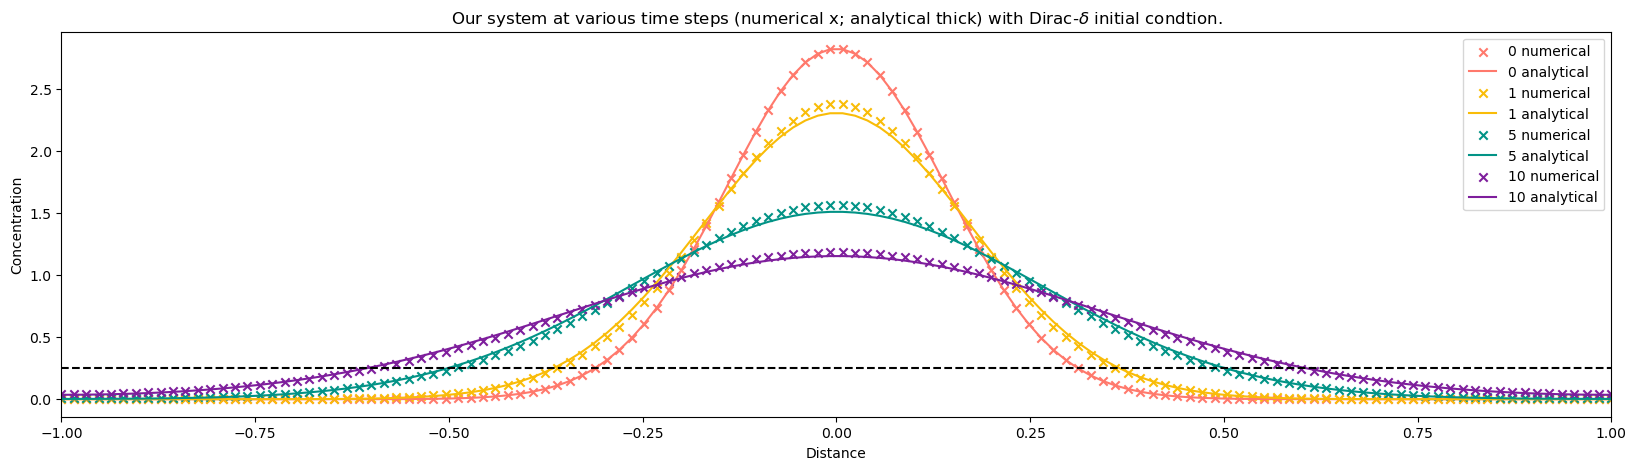

System uses N = 2000 time points, M = 250 space points, a total time of T = 10, with dt, dx = 0.004995000000000001, 0.008000000000000007.


In [6]:
# recall again: n is time, m is space
U_2 = np.zeros((N+1, M+1))
N_analytic = int(1e4)

# set initial condition to be dirac-delta for the smallest time we have
U_2[0] = analytical_sol(x, start_time, N_analytic)
U_ex_2 = np.zeros((N+1, M+1))

for n in range(0, N):
    pseudo_inv = spsolve(A, U_2[n])
    U_2[n + 1] = pseudo_inv

times = [0, 1, 5, 10]

fig, ax = plt.subplots(1, 1, figsize = (20, 5))
for i, time in enumerate(times):
    # numerical
    ax.scatter(x[::2], U_2[time][::2], label = f'{time} numerical', color = colours[i], marker = 'x')

    # analytical
    ax.plot(x[::2], analytical_sol(x[::2], t[time], N_analytic), color = colours[i], label = f'{time} analytical')
    
    ax.set_title(r'Our system at various time steps (numerical x; analytical thick) with Dirac-$\delta$ initial condtion.')
    ax.set_xlabel("Distance")
    ax.set_ylabel("Concentration")
    ax.set_xlim(-1, 1)

ax.plot(x[::2], [0.25] * len(x[::2]), color = "black", linestyle = 'dashed')

plt.legend(loc = 'best')
plt.show()

print(f'System uses N = {N} time points, M = {M} space points, a total time of T = {T}, with dt, dx = {dt}, {dx}.')

### Implementing Scrubbers
Consider the problem with a sink term,
$$
\partial_\tau u(\xi, \tau) = \partial_{\xi\xi}(\xi, \tau) - ku(\xi, \tau),\tag{3}
$$
where $\xi \in [-1, 1]$, $\tau \geq 0$ (or really $\tau \geq \epsilon$), and $k$ is some constant $k > 0$. It can be shown (will write the derivation here)#### that the backward's Euler method then yields
$$
U_m^n = -CU_{m+1}^{n+1} + (1+2C+D)U_m^{n+1} - CU_{m-1}^n, \qquad C = \frac{D\Delta t}{(\Delta x)^2}, \quad D = \Delta t k.
$$

The first implementation of this sink term will assume that the scrubbers are passive, and work proportional to the concentration of gas at each point. So that means $k = k(x)$ where, for the sink strength $k_s$,
$$
k(x) = \begin{cases}
        k_s, \quad &k \in [\text{some interval around }x],\\
        0, &\text{otherwise}.
    \end{cases}
$$

Quick note before I forget it - what if scrubbers depended on time too, say $k = k(x, t)$.

Note that the tridiagonal matrix formulation is the same as before, just with the diagonal entries changed *in the interval around $x$ where the scrubber is placed.* 

1. Define some length of the space $w$ that we want the scrubbers to work in, say $w = 0.1$.
2. Calculate the number of space-steps that correspond to this length, i.e. $n = w / \Delta x$. 
3. If a scrubber is placed at some $x_s$, then edit all rows in the matrix (i.e. space-interval $[x - n/2, x + n/2]$). Just need to edit the diagonal by adding $D = k\Delta t$.
4. You will need to fix $k$, say $k = 0.1$. It is proportional to the gas at that point... so it should be reasonable for any $k \in (0, 1)$.

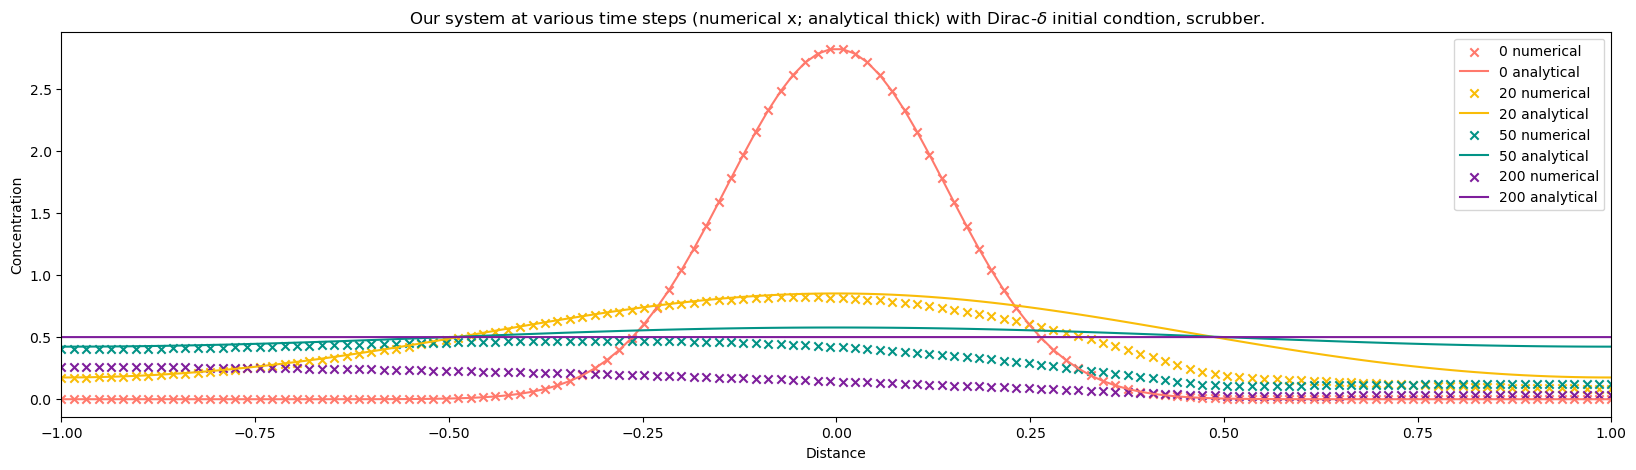

System uses N = 2000 time points, M = 250 space points, a total time of T = 10, with dt, dx = 0.004995000000000001, 0.008000000000000007.


In [16]:
# ---- Scrubber Implementations ----
w = 0.1
k_s = 10
D = dt * k_s

# introduce a scrubber halfway on the real axis?
x_s = 1.5 // dx
n_s = w // dx

# need n to be even
if (n_s % 2 != 0):
    n_s += 1


# ---- adding the sink terms around the scrubber x_s = 0.5 ----
start_point = x_s - (n_s // 2)
diag_index = int(start_point)

# convert A from a sparse array so it can be edited
A_notsparse = A.toarray()

for i in range(int(n_s)):
    # diagonal elements
    A_notsparse[diag_index][diag_index] += D
    diag_index += 1

A = scipy.sparse.csr_matrix(A_notsparse)

# -------------------------------------------------
# same implementation as before
# recall again: n is time, m is space
U_3 = np.zeros((N+1, M+1))
N_analytic = int(1e4)

# set initial condition to be dirac-delta for the smallest time we have
U_3[0] = analytical_sol(x, start_time, N_analytic)
U_ex_3 = np.zeros((N+1, M+1))

for n in range(0, N):
    pseudo_inv = spsolve(A, U_3[n])
    U_3[n + 1] = pseudo_inv

times = [0, 20, 50, 200]

fig, ax = plt.subplots(1, 1, figsize = (20, 5))
for i, time in enumerate(times):
    # numerical
    ax.scatter(x[::2], U_3[time][::2], label = f'{time} numerical', color = colours[i], marker = 'x')

    # analytical
    ax.plot(x[::2], analytical_sol(x[::2], t[time], N_analytic), color = colours[i], label = f'{time} analytical')
    
    ax.set_title(r'Our system at various time steps (numerical x; analytical thick) with Dirac-$\delta$ initial condtion, scrubber.')
    ax.set_xlabel("Distance")
    ax.set_ylabel("Concentration")
    ax.set_xlim(-1, 1)


plt.legend(loc = 'best')
plt.show()

print(f'System uses N = {N} time points, M = {M} space points, a total time of T = {T}, with dt, dx = {dt}, {dx}.')

You need to redefine A between iterations.
Make a function for A.

### Solution with Thresholding
Want to find $t^*$ such that $C(x^*, t^*) = C^*$.

In [ ]:
x_star = 0.5
C_star = 0.40

# x = np.linspace(-1, 1, M + 1) :: 0.5 is 3\4th of the way through
x_loc = 3 * len(x) // 4
print(x[x_loc])

# U[:, x_loc] will print the concentrations at x_loc for all time steps
concentrations_at_x = U_2[:, x_loc]
first_val = next(conc for conc in concentrations_at_x if conc > C_star)
first_val_index = np.where(concentrations_at_x == first_val)
print(first_val_index)


# want the first time that satisfies C(x, t) > C*
print(U_2[:, x_loc][0:10])

0.504
(array([11]),)
[0.00492551 0.04028862 0.08685516 0.13692437 0.18567885 0.23057489
 0.27054808 0.30539428 0.3353625  0.36091003]


In [ ]:
test_list = [1, 2, 3, 4, 5, 6, 7]
a = next(i for i in test_list if i > 3)
a

4